# 土木のためのPython入門⑥ SciPyで科学技術計算｜補間・数値積分・数値微分・最適化

**著者:** skyblueao77  
**タグ:** 初心者, 土木工学, scipy, Python

---

> **この記事の対象者**
>
> * Pythonをこれから土木工学に活用したい方
> * NumPy、pandas、Matplotlibを学んだ方
> * 土木工学における数値計算をPythonで行ってみたい方
> * 科学技術計算やデータ分析に興味がある方
> * 生成AIを使いながら、Pythonによる技術計算を学びたい方

> **この記事を読む前に**
>
> * 本記事は筆者個人の学習記録であり、所属する大学や特定の団体の公式見解ではありません。
> * 本記事の内容には十分注意を払っていますが、正確性や完全性を保証するものではありません。
> * 本記事を参考にする場合は、必ずご自身でも最新の公式ドキュメント等をご確認ください。
> * 特に実務上の設計・安全性の判断には、関係法令、設計基準、専門家による確認等が必要です。
> * 本記事の利用によって生じたいかなる損害についても、筆者は責任を負いかねます。

## はじめに

これまでの記事では、Pythonの基本文法に加えて、

* pandasによるデータ整理
* Matplotlibによる可視化
* NumPyによる配列計算

を紹介してきました。

前回の記事はこちら↓  
https://qiita.com/skyblueao77/items/dfc9a12c147230814424

ここまで学ぶと、

```text
データを読み込む
↓
データを整理する
↓
数値計算を行う
↓
グラフにする
```

という一連の処理ができるようになります。

しかし、土木工学でPythonを利用していくと、補間、数値積分、方程式の求解、最適化、統計解析など、より専門的な計算が必要になる場面があります。

そこで活用できる代表的なライブラリが **SciPy** です。

2026年8月現在、SciPyの最新安定版は **1.18.0** です。SciPyは継続的に開発されており、数値積分、補間、最適化、統計、線形代数、信号処理など、科学技術計算に必要な幅広い機能が提供されています。

また、2026年現在は生成AIによってコードを書くこと自体は以前より容易になっています。

そのため、単にSciPyの関数を暗記するだけでなく、

> **どのような問題を、どのような数値計算として定式化し、どの手法を選び、得られた結果が妥当かを判断する**

ことが重要になります。

今回は、土木工学でも利用しやすいSciPyの基本機能を紹介します。

---

## 1. SciPyとは？

SciPy（Scientific Python）は、Pythonで科学技術計算を行うためのオープンソースライブラリです。

NumPyを基盤としながら、より専門的な科学技術計算の機能を提供しています。

代表的なサブパッケージには次のようなものがあります。

| サブパッケージ | 主な用途 |
| --- | --- |
| `scipy.optimize` | 最適化・方程式の求解 |
| `scipy.integrate` | 数値積分・常微分方程式 |
| `scipy.differentiate` | 数値微分・ヤコビアン・ヘッセ行列 |
| `scipy.interpolate` | 補間 |
| `scipy.linalg` | 線形代数 |
| `scipy.stats` | 統計・確率分布 |
| `scipy.signal` | 信号処理 |
| `scipy.sparse` | 疎行列・疎配列 |
| `scipy.spatial` | 空間・距離・幾何計算 |

すべてを覚える必要はありません。

まずは、

```text
NumPy
↓
配列・ベクトル化・基本的な数値計算

SciPy
↓
より専門的な科学技術計算
```

という関係を理解しておけば十分です。

---

## 2. SciPyをインストールする

SciPyは通常のPython環境にインストールできます。

Google Colabでは一般的な環境でSciPyを利用できるため、通常は追加インストールを意識する必要はありません。

uvを利用している場合は、プロジェクトディレクトリで、

```bash
uv add scipy
```

を実行します。

In [1]:
import scipy

print(scipy.__version__)

1.18.0


2026年8月現在の最新安定版は1.18.0です。

なお、PythonやNumPyとの対応関係はSciPyのバージョンによって変化します。

そのため、環境構築時には古い記事に書かれたバージョンではなく、使用するSciPyの公式ドキュメントを確認することをおすすめします。

---

## 3. NumPyとSciPyの関係

SciPyを理解するためには、NumPyとの関係を理解しておくと分かりやすいでしょう。

NumPyでは、配列を使った計算を効率的に行えます。

In [2]:
import numpy as np

x = np.array([1, 2, 3, 4, 5])

print(x * 2)

[ 2  4  6  8 10]


このように、NumPyはPythonで数値計算を行うための重要な基盤です。

一方、SciPyではNumPyの配列などを利用しながら、より専門的なアルゴリズムを利用できます。

イメージすると、
```text
Python
│
├─ NumPy
│  └─ 数値計算の基盤
│     ├─ 配列
│     ├─ ベクトル化
│     ├─ 基本的な数値演算
│     └─ 線形代数など
│
└─ SciPy
   └─ 科学技術計算
      ├─ 補間
      ├─ 積分
      ├─ 微分
      ├─ 方程式の求解
      ├─ 最適化
      ├─ 統計
      ├─ 信号処理
      └─ その他の科学技術計算
```
という関係です。

ただし、NumPyとSciPyは上下関係にあるわけではありません。

NumPyは配列操作や基本的な数値計算を担い、SciPyはその上で補間・積分・最適化などの専門的な計算機能を提供します。

実際の科学技術計算では、両者を組み合わせて利用することが多くなります。

---

## 4. 補間

土木工学では、観測データを扱う機会が数多くあります。

例えば、水位を10分ごとに観測しているとします。

```python
import numpy as np

time = np.array([0, 10, 20, 30])
water_level = np.array([1.2, 1.8, 2.5, 2.0])
```

このとき、`15分` の水位は直接観測されていません。

このような場合に利用できるのが **補間（interpolation）** です。

### 4.1 線形補間

補間の基本的な方法の一つが線形補間です。

現在のSciPyでは、以前の記事などでよく使われていた `scipy.interpolate.interp1d` は **legacy API** とされています。

公式ドキュメントでは、`interp1d`は今後新機能が追加される対象ではなく、新しいコードではより新しい補間クラスを利用することが推奨されています。

単純な1次元の線形補間であれば、`numpy.interp`を利用する方法もあります。

In [3]:
import numpy as np

time = np.array([0, 10, 20, 30])
water_level = np.array([1.2, 1.8, 2.5, 2.0])

water_level_15 = np.interp(
    15,
    time,
    water_level
)

print(water_level_15)

2.15


10分と20分の観測値の間を線形に補間しています。

### 4.2 SciPyの補間手法を使い分ける

SciPyの`scipy.interpolate`には、さまざまな補間手法があります。

例えば、

```text
CubicSpline
    → 3次スプライン補間

PchipInterpolator
    → 形状保存型の補間

Akima1DInterpolator
    → Akima補間

RegularGridInterpolator
    → 規則格子上の多次元補間

LinearNDInterpolator
    → 非構造データの多次元補間

RBFInterpolator
    → 放射基底関数による補間
```

などがあります。

つまり、

> 「補間するなら、とりあえず`interp1d`」

という考え方は、2026年のSciPyでは適切ではありません。

データの性質や目的に応じて手法を選択する必要があります。

### 4.3 補間を使うときの注意

補間によって得られた値は、実際に観測された値ではありません。

例えば、

```text
0 ─── 10 ─── 20 ─── 30
```

という観測値から、`15分` の値を推定するのは補間です。

一方、`30分より後の40分` を推定する場合は外挿になります。

補間と外挿は区別する必要があります。

特に土木工学の実データでは、

```text
実測値
推定値
補間値
外挿値
```

を明確に区別して扱うことが重要です。

また、補間方法によっては観測値の間で不自然な振動やオーバーシュートが発生する場合があります。

したがって、

> 「グラフが滑らかになったから正しい」

とは限りません。

データの物理的性質を考えて補間方法を選ぶ必要があります。

---

## 5. 数値積分と土木工学

次は **数値積分** です。

例えば、

$$\int_0^1 x^2 dx$$

を考えます。

解析的には、

$$\frac{1}{3}$$

となります。

SciPyでは `scipy.integrate.quad` を利用できます。

In [4]:
from scipy.integrate import quad

def f(x):
    return x**2

result, error = quad(f, 0, 1)

print(result)

0.33333333333333337


`quad()`は指定した区間における定積分を数値的に計算します。公式ドキュメントでは、内部でQUADPACKを利用することも説明されています。

積分は土木工学のさまざまな場面で登場します。

例えば、

* 断面積
* 体積
* 流量
* 仕事
* 分布荷重
* 重心
* モーメント

などです。

例えば、位置によって幅が変化する断面を考えます。

幅を $w(x)$ とすると、区間 $a$ から $b$ までの面積は、

$$A=\int_a^b w(x)dx$$

と表現できます。

Pythonでは次のように計算できます。

In [5]:
from scipy.integrate import quad

def width(x):
    return 2 + 0.1 * x

area, error = quad(width, 0, 10)

print(area)

25.0


ここで重要なのは、

> Pythonが「面積」という概念を理解しているわけではない

ということです。

人間が土木工学上の問題を数式として定式化し、その数式を数値計算としてPythonに実行させています。

---

## 6. 数値微分

SciPyでは、数値積分だけでなく **数値微分** も扱えます。

現在のSciPyには `scipy.differentiate` という数値微分用のサブパッケージがあります。

`scipy.differentiate.derivative` は、有限差分を利用して関数の1階微分を数値的に推定する関数です。微分値だけでなく、推定誤差や収束状態なども取得できます。

例えば、 $f(x)=x^2$ の $x=3$ における微分を求めてみます。

In [6]:
from scipy.differentiate import derivative

def f(x):
    return x**2

result = derivative(f, 3)

print(f"微分値: {result.df}")
print(f"推定誤差: {result.error}")
print(f"収束判定: {result.success}")

微分値: 5.999999999999972
推定誤差: 2.842170943040401e-14
収束判定: True


理論上、$f'(x)=2x$ なので、$f'(3)=6$ となります。

`derivative()`は有限差分によって微分値を近似します。

戻り値には、例えば次の情報が含まれます。

```text
df
→ 推定された微分値

error
→ 微分値の推定誤差

success
→ 計算が収束したかどうか
```

そのため、実際の数値計算では、次のように計算が正常に収束したかを確認することもできます。

In [7]:
result = derivative(f, 3)

if result.success:
    print(f"微分値: {result.df}")
else:
    print("数値微分が収束しませんでした")

微分値: 5.999999999999972


ただし、数値微分はあくまで近似計算です。

特に実測データを直接微分する場合には、観測誤差やノイズが微分によって増幅されることがあります。そのため、土木工学の実データを扱う場合には、データのノイズやサンプリング間隔、採用する数値微分法などを考慮する必要があります。

また、数値微分と解析的な微分は区別しましょう。

例えば、$f(x)=x^2$ であれば $f'(x)=2x$ と数学的に求められます。

一方、`scipy.differentiate.derivative`は、関数を評価した値から数値的に微分を推定します。

したがって、

> **解析的に微分できる場合でも、数値計算によって微分値を求めたい場合に利用できる**

という位置付けで考えると分かりやすいでしょう。

なお、`scipy.differentiate`にはヤコビアンやヘッセ行列など、多変数関数を扱う機能もあります。今回は1変数関数の数値微分を押さえておけば十分です。

---

## 7. 方程式を数値的に解く

土木工学では、方程式を解く場面も多くあります。

例えば、$x^2-2=0$ を考えます。

解析的には、$x=\sqrt{2}$ および $x=-\sqrt{2}$ が解です。

しかし、実際の工学問題では、解析的に簡単に解ける形にならないことがあります。

そのような場合には数値解法を利用できます。

SciPyでは `scipy.optimize.root_scalar` などを利用できます。

In [8]:
from scipy.optimize import root_scalar

def f(x):
    return x**2 - 2

result = root_scalar(
    f,
    bracket=[0, 2]
)

print(result.root)

1.4142135623731364


ここで注意したいのは、

> 数値解法は、どんな問題でも自動的に正しい答えを出してくれるわけではない

ということです。

例えば、

```text
解が存在するのか
↓
どの範囲に存在するのか
↓
どの数値解法を使うのか
↓
十分な精度で収束しているのか
↓
その解が工学的に意味を持つのか
```

という確認が必要です。

つまり、`result = root_scalar(...)` と書けることよりも、

> なぜこの方法で、この条件を設定しているのか

を理解することの方が重要です。

---

## 8. 最適化

SciPyの重要な機能の一つが **最適化（optimization）** です。

工学では、

> ある条件のもとで最も望ましい値を求める

という問題が頻繁に登場します。

例えば、

* コストを最小化する
* 重量を最小化する
* 距離を最小化する
* エネルギーを最小化する
* 制約条件のもとで性能を最大化する

といった問題です。

SciPyでは `scipy.optimize` を利用できます。

例えば、$f(x)=(x-3)^2+1$ の最小値を求めます。

In [9]:
from scipy.optimize import minimize

def f(x):
    return (x[0] - 3)**2 + 1

result = minimize(
    f,
    x0=[0]
)

print(result.x)
print(result.fun)

[3.00000003]
1.0000000000000009


この関数は、$x=3$ で最小値 $f(x)=1$ を取ります。

実際の土木工学では、単純に関数の最小値を探せばよいとは限りません。

例えば、「コストを最小化したい」としても、

```text
安全性を満たす
材料強度を満たす
変形量を許容値以下にする
施工条件を満たす
予算を超えない
```

といった制約条件があります。

したがって、実際の最適化問題では、

```text
目的関数
+
制約条件
+
設計変数
```

という形で問題を定式化します。

SciPyの `optimize` には、こうした制約付き最適化を扱うための機能もあります。

---

## 9. 統計計算

SciPyには統計・確率分布を扱う `scipy.stats` もあります。

例えば正規分布を考えてみます。

In [10]:
from scipy.stats import norm

x = 0

print(norm.pdf(x))

0.3989422804014327


`pdf()`は確率密度関数の値を計算します。

土木工学では、

* 降雨量
* 河川流量
* 地盤データ
* 材料強度
* 観測誤差
* 信頼性解析
* データのばらつき

など、統計的な考え方が必要になる場面があります。

ただし、

> **SciPyで計算できることと、統計的に正しい分析ができることは別**

です。

例えば統計検定では、

* 何を検定したいのか
* 帰無仮説は何か
* データはどのような性質なのか
* 前提条件を満たしているか
* p値をどのように解釈するか

といった統計学上の知識が必要になります。

---

## 10. NumPy・pandas・Matplotlib・SciPyを組み合わせる

ここまで学んだライブラリは、単独で利用する必要はありません。

むしろ、実際の土木データ分析では複数のライブラリを組み合わせることが多くなります。

例えば、

```text
pandas
↓
データを読み込む・整理する
↓
NumPy
↓
配列・数値計算
↓
SciPy
↓
補間・積分・最適化・統計など
↓
Matplotlib
↓
結果を可視化する
```

という流れです。

次の章では、この考え方を水位データの補間で確認してみます。

---

## 11. 実例：水位データを補間して可視化する

ここでは、観測された水位データを例にします。

今回は `PchipInterpolator` を利用します。

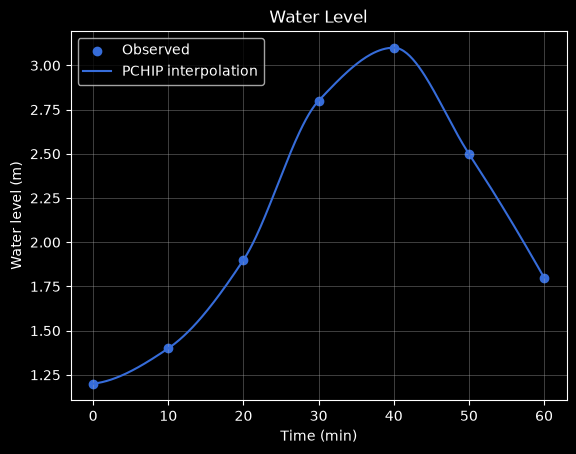

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# 観測データ
time = np.array([
    0, 10, 20, 30, 40, 50, 60
])

water_level = np.array([
    1.2,
    1.4,
    1.9,
    2.8,
    3.1,
    2.5,
    1.8
])

# PCHIP補間
interpolation = PchipInterpolator(
    time,
    water_level
)

time_interpolated = np.linspace(
    0,
    60,
    300
)

water_level_interpolated = interpolation(
    time_interpolated
)

# グラフ描画
plt.scatter(
    time,
    water_level,
    label="Observed"
)

plt.plot(
    time_interpolated,
    water_level_interpolated,
    label="PCHIP interpolation"
)

plt.xlabel("Time (min)")
plt.ylabel("Water level (m)")
plt.title("Water Level")

plt.legend()
plt.grid()

plt.show()

ここでは、

```text
NumPy
→ 数値データを配列として扱う

SciPy
→ 観測点の間を補間する

Matplotlib
→ 結果を可視化する
```

という役割分担になっています。

なお、ここで `PchipInterpolator` を使ったのは、単にグラフを滑らかにするためではありません。

補間方法にはそれぞれ特徴があり、データの性質に応じて選択する必要があります。SciPy公式ドキュメントでも、`PchipInterpolator`、`CubicSpline`、`Akima1DInterpolator`などがそれぞれ異なる補間手法として整理されています。

---

## 12. SciPyですべて解決できるわけではない

SciPyは非常に強力なライブラリですが、土木工学の問題をすべてSciPyだけで解決できるわけではありません。

例えば、

* GIS
* CAD
* BIM
* 有限要素法
* 数値流体解析
* 構造解析
* 地盤解析
* 交通シミュレーション

などには、それぞれ専門的なソフトウェアやライブラリがあります。

SciPyは土木工学専用の解析ソフトではありません。

実務では、

```text
専門ソフトウェア
      ↓
解析
      ↓
Python
      ↓
データ処理
      ↓
統計解析
      ↓
可視化
      ↓
レポート・結果整理
```

というように、専門ソフトウェアとPythonを組み合わせることで強力な環境を構築できます。

また、専門ソフトウェアがPython APIを提供している場合には、解析前後の処理をPythonから自動化することもできます。

---

## 13. 生成AI時代にSciPyを学ぶ意味

2026年現在は生成AIによって、

```text
「SciPyでこの計算をしたい」
```

と説明するだけでも、コードの候補を生成してもらえるようになっています。

例えば、

> 10分間隔の河川水位データをPCHIPで補間して、観測値と一緒にMatplotlibで表示したい

といった要求を生成AIに説明すれば、SciPyを使ったコードを生成してもらうことができます。

そのため、

> 「SciPyの関数を全部暗記しなければならない」

という考え方は、以前ほど重要ではありません。

しかし、だからといってSciPyを学ぶ必要がなくなったわけではありません。

重要なのは、

```text
問題を理解する
↓
数学・物理モデルにする
↓
適切な数値手法を選ぶ
↓
AIなどを利用して実装する
↓
コードを確認する
↓
計算結果を検証する
↓
工学的に解釈する
```

という流れです。

例えば生成AIに、「河川水位データを補間するPythonコードを書いて」と依頼したとします。

AIが `from scipy.interpolate import interp1d` を使ったコードを返してくる可能性があります。

コード自体は動作するかもしれません。しかし、2026年現在のSciPy公式ドキュメントでは `interp1d` はlegacy APIとして扱われ、新しいコードではより現代的な補間手法を使うことが推奨されています。

つまり、

```text
AIがコードを生成した
↓
コードが動いた
↓
正しい
```

とは限りません。

必要なのは、

```text
AIが生成
↓
公式ドキュメントを確認
↓
使用しているAPIを確認
↓
入力条件を確認
↓
計算結果を確認
↓
工学的妥当性を確認
```

という流れです。

これはSciPyに限った話ではありません。Pythonを土木工学で利用する場合には、非常に重要な考え方になります。

---

## 14. 今回覚えておきたいこと

今回のポイントを整理します。

### SciPyとは

Pythonで科学技術計算を行うためのライブラリです。

### NumPyとの関係

NumPyが配列や基本的な数値計算の基盤を提供する一方、SciPyではより専門的な科学技術計算を扱えます。

### 主な機能

```text
scipy.interpolate
    → 補間

scipy.integrate
    → 数値積分・微分方程式

scipy.differentiate
    → 数値微分・ヤコビアン・ヘッセ行列

scipy.optimize
    → 最適化・方程式の求解

scipy.stats
    → 統計・確率分布

scipy.linalg
    → 線形代数

scipy.signal
    → 信号処理

scipy.sparse
    → 疎行列・疎配列
```

すべてを暗記する必要はありません。

重要なのは、

> **どのような問題に、どのような数値計算手法を使えばよいかを判断できること**

です。

---

## まとめ

今回は、Pythonで科学技術計算を行うための代表的なライブラリであるSciPyを紹介しました。

これまで学んできた、

```text
Python
 ↓
pandas
 ↓
Matplotlib
 ↓
NumPy
 ↓
SciPy
```

という知識を組み合わせることで、単純なPythonプログラムから、より実践的な土木データ分析・数値計算へ進むことができます。

SciPyでは、補間、数値積分、数値微分、方程式の求解、最適化、統計解析など、さまざまな科学技術計算を扱えます。

また、PythonライブラリのAPIは時間とともに変化します。

従来よく使われていた `interp1d` がlegacy APIとなっているように、以前の記事や生成AIが提示したコードをそのまま利用するのではなく、公式ドキュメントを確認する習慣が重要です。

そして、生成AIが普及した2026年では、すべての関数やコードを暗記することよりも、

```text
何を計算したいのか
↓
どのように数式化するのか
↓
どの数値手法を使うのか
↓
どのライブラリを使うのか
↓
生成されたコードは適切か
↓
計算結果は妥当か
↓
工学的に何を意味するのか
```

という一連の流れを理解することが重要です。

土木工学でPythonを利用する目的は、Pythonのコードを書くことそのものではありません。

**土木工学上の問題を数理モデルとして表現し、それをコンピュータで計算し、得られた結果を工学的に解釈できるようになること**にあります。

SciPyは、そのための重要な道具の一つです。

次回以降は、NumPy・pandas・Matplotlib・SciPyを組み合わせ、実際の土木工学データを対象とした分析へ進んでいきます。

---

### 参考

SciPyは公式ドキュメントを確認しながら利用することをおすすめします。

* [SciPy公式サイト](https://scipy.org/)
* [SciPy公式ドキュメント](https://docs.scipy.org/doc/scipy/)
* [SciPy 1.18.0のリリース情報](https://scipy.org/news/)